**D2 Receptor Bioactivity — Exploratory Data Analysis**

Exploratory analysis of 1,580 IC50 records against the human D2 dopamine 
receptor (CHEMBL217) ingested via the ETL pipeline in `etl.py`.

Sections:
1. Data loading and null summary
2. pIC50 distribution (modeling target)
3. Lipinski descriptor distributions
4. Descriptor correlation matrix

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

DB_URL = (
    f"postgresql+psycopg2://"
    f"{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}"
    f"/{os.environ['DB_NAME']}"
)

engine = create_engine(DB_URL, echo=False)

Next, I want to generally explore the data collected from the ETL pipeline. I'll make a dataframe for each table generated and view the first 5 rows.

In [2]:
compounds_query = """
    SELECT * FROM qsar.compounds
"""

compounds = pd.read_sql(compounds_query, engine)
print(f"compounds: {compounds.shape}")
compounds.head()

compounds: (1279, 12)


,id,chembl_id,canonical_smiles,pref_name,mw,alogp,hbd,hba,psa,rtb,ro5_violations,created_at
0,1,CHEMBL303519,c1cnc(N2CCN(Cc3cccc4c3Cc3ccccc3-4)CC2)nc1,NaN,342.45,3.37,0.0,4.0,32.26,3.0,0.0,2026-05-12 20:19:26.796508+00:00
1,2,CHEMBL292943,COc1ccc(-c2cccc(CN3CCN(c4ncccn4)CC3)c2)cc1,NaN,360.46,3.47,0.0,5.0,41.49,5.0,0.0,2026-05-12 20:19:26.796508+00:00
2,3,CHEMBL61682,Fc1ccc(-c2cncc(CN3CCN(c4ccccc4F)CC3)c2)cc1,NaN,365.43,4.35,0.0,3.0,19.37,4.0,0.0,2026-05-12 20:19:26.796508+00:00
3,4,CHEMBL64487,COc1ccccc1-c1cccc(CN2CCN(c3ncccn3)CC2)c1,NaN,360.46,3.47,0.0,5.0,41.49,5.0,0.0,2026-05-12 20:19:26.796508+00:00
4,5,CHEMBL64597,c1cnc(N2CCN(Cc3cccc(-c4ccsc4)c3)CC2)nc1,NaN,336.46,3.53,0.0,5.0,32.26,4.0,0.0,2026-05-12 20:19:26.796508+00:00


In [3]:
bioactivity_query = """
    SELECT * FROM qsar.bioactivity
"""

bioactivity = pd.read_sql(bioactivity_query, engine)
print(f"bioactivity: {bioactivity.shape}")
bioactivity.head()

bioactivity: (1580, 10)


,id,compound_id,assay_id,activity_type,value,relation,units,pic50,activity_comment,created_at
0,1,1,1,IC50,9800.0,=,nM,5.01,NaN,2026-05-12 20:19:26.796508+00:00
1,2,2,1,IC50,50.0,=,nM,7.30,NaN,2026-05-12 20:19:26.796508+00:00
2,3,3,1,IC50,25.0,=,nM,7.60,NaN,2026-05-12 20:19:26.796508+00:00
3,4,4,1,IC50,360.0,=,nM,6.44,NaN,2026-05-12 20:19:26.796508+00:00
4,5,5,1,IC50,300.0,=,nM,6.52,NaN,2026-05-12 20:19:26.796508+00:00


In [8]:
assays_query = """
    SELECT * FROM qsar.assays
"""

assays = pd.read_sql(assays_query, engine)
print(f"assays: {assays.shape}")
assays.head()

assays: (201, 5)


,id,chembl_id,assay_type,description,created_at
0,1,CHEMBL671073,B,Binding affinity to cloned human Dopamine rece...,2026-05-12 20:19:26.796508+00:00
1,2,CHEMBL671342,B,Binding affinity of compound to Dopamine recep...,2026-05-12 20:19:26.796508+00:00
2,3,CHEMBL672303,B,Inhibitory concentration against binding of Do...,2026-05-12 20:19:26.796508+00:00
3,4,CHEMBL671074,B,Binding affinity to dopamine receptor D2 clone...,2026-05-12 20:19:26.796508+00:00
4,5,CHEMBL671076,B,Binding affinity towards human Dopamine recept...,2026-05-12 20:19:26.796508+00:00


After viewing all tables, I'll make one large DataFrame with all the feilds of interest combined

In [10]:
qsar_raw_query = """
    SELECT
        c.chembl_id,
        c.canonical_smiles,
        c.pref_name,
        c.mw,
        c.alogp,
        c.hbd,
        c.hba,
        c.psa,
        c.rtb,
        c.ro5_violations,
        b.value AS ic50,
        b.pic50,
        b.relation,
        b.activity_comment,
        a.assay_type,
        a.description AS assay_description
    FROM qsar.bioactivity b
    JOIN qsar.compounds c ON b.compound_id = c.id
    JOIN qsar.assays a ON b.assay_id = a.id
"""

qsar_raw = pd.read_sql(qsar_raw_query, engine)
print(f"qsar_raw: {qsar_raw.shape}")
qsar_raw.head()

qsar_raw: (1580, 16)


,chembl_id,canonical_smiles,pref_name,mw,alogp,hbd,hba,psa,rtb,ro5_violations,ic50,pic50,relation,activity_comment,assay_type,assay_description
0,CHEMBL303519,c1cnc(N2CCN(Cc3cccc4c3Cc3ccccc3-4)CC2)nc1,NaN,342.45,3.37,0.0,4.0,32.26,3.0,0.0,9800.0,5.01,=,NaN,B,Binding affinity to cloned human Dopamine rece...
1,CHEMBL292943,COc1ccc(-c2cccc(CN3CCN(c4ncccn4)CC3)c2)cc1,NaN,360.46,3.47,0.0,5.0,41.49,5.0,0.0,50.0,7.30,=,NaN,B,Binding affinity to cloned human Dopamine rece...
2,CHEMBL61682,Fc1ccc(-c2cncc(CN3CCN(c4ccccc4F)CC3)c2)cc1,NaN,365.43,4.35,0.0,3.0,19.37,4.0,0.0,25.0,7.60,=,NaN,B,Binding affinity to cloned human Dopamine rece...
3,CHEMBL64487,COc1ccccc1-c1cccc(CN2CCN(c3ncccn3)CC2)c1,NaN,360.46,3.47,0.0,5.0,41.49,5.0,0.0,360.0,6.44,=,NaN,B,Binding affinity to cloned human Dopamine rece...
4,CHEMBL64597,c1cnc(N2CCN(Cc3cccc(-c4ccsc4)c3)CC2)nc1,NaN,336.46,3.53,0.0,5.0,32.26,4.0,0.0,300.0,6.52,=,NaN,B,Binding affinity to cloned human Dopamine rece...


I want to get a sense of the structure of the data, missing values, etc.

In [7]:
qsar_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   chembl_id          1580 non-null   str    
 1   canonical_smiles   1578 non-null   str    
 2   pref_name          196 non-null    str    
 3   mw                 1578 non-null   float64
 4   alogp              1566 non-null   float64
 5   hbd                1566 non-null   float64
 6   hba                1566 non-null   float64
 7   psa                1566 non-null   float64
 8   rtb                1566 non-null   float64
 9   ro5_violations     1566 non-null   float64
 10  ic50               1572 non-null   float64
 11  pic50              1091 non-null   float64
 12  relation           1568 non-null   str    
 13  activity_comment   269 non-null    str    
 14  assay_type         1580 non-null   str    
 15  assay_description  1580 non-null   str    
dtypes: float64(9), str(7)
memory usage:

In [11]:
null_summary = qsar_raw.isnull().sum().to_frame(name="missing")
null_summary["pct_missing"] = (null_summary["missing"] / len(qsar_raw) * 100).round(2)
null_summary[null_summary["missing"] > 0]

,missing,pct_missing
canonical_smiles,2,0.13
pref_name,1384,87.59
mw,2,0.13
alogp,14,0.89
hbd,14,0.89
hba,14,0.89
psa,14,0.89
rtb,14,0.89
ro5_violations,14,0.89
ic50,8,0.51


Observations:
- 2 missing values for canonical_smiles - these entries will probably need to be dropped
- Most compounds missing a name - this is fine since this is just metadata and will not be included in modeling
- missing values for a lot of the features that will be used for modeling (alogp, hbd, hba, psa, rtb, ro5, ic50)
- pic50 has different number of values than ic50 - these are likely censored values but need to investigate to be sure
- relation missing some values, which my be an issue since relation distinguishes valid from invalid entries - will investigate
- activity comment has lots of missing values, again not too important since this is metadata

Target for modeling will be pIC50. Let's look at the distribution and summary statistics for those values.

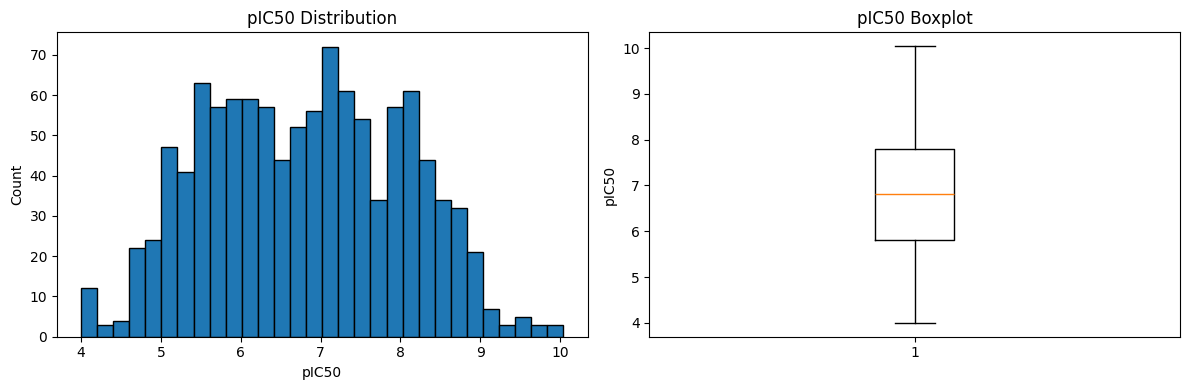

count    1091.00
mean        6.81
std         1.22
min         4.00
25%         5.82
50%         6.82
75%         7.80
max        10.04
Name: pic50, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram
axes[0].hist(qsar_raw["pic50"].dropna(), bins=30, edgecolor="black")
axes[0].set_xlabel("pIC50")
axes[0].set_ylabel("Count")
axes[0].set_title("pIC50 Distribution")

# boxplot
axes[1].boxplot(qsar_raw["pic50"].dropna())
axes[1].set_ylabel("pIC50")
axes[1].set_title("pIC50 Boxplot")

plt.tight_layout()
plt.show()

print(qsar_raw["pic50"].describe().round(2))

Observations:
- visually, data looks pretty much normally distributed
- mean and median are almost identical (~6.8)
- range between 4-10, centered around 6.5-7
- no extreme outliers
- distribution should be well-suited for regression

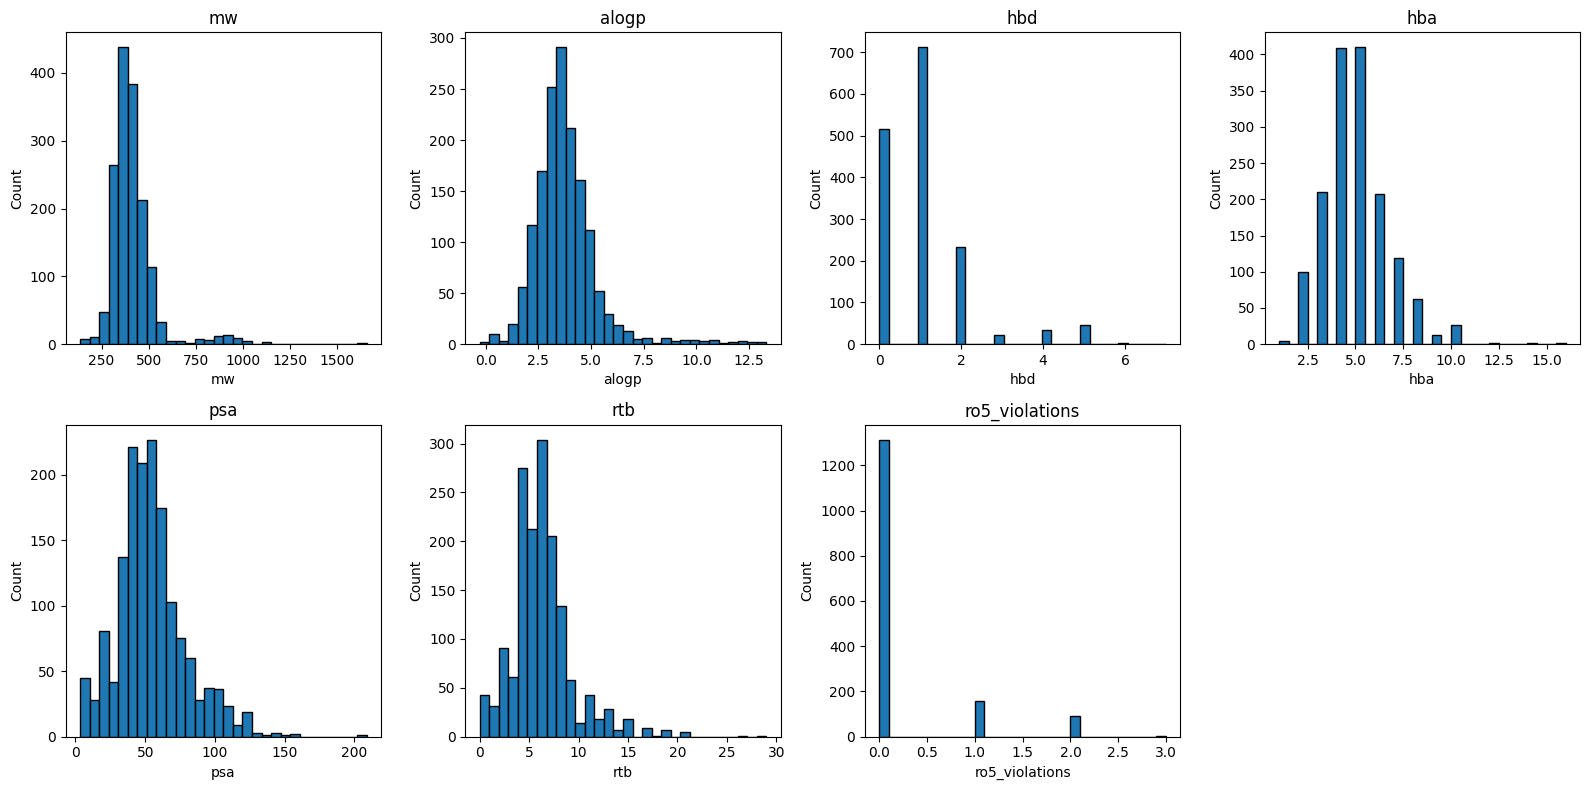

            mw    alogp      hbd      hba      psa      rtb  ro5_violations
count  1578.00  1566.00  1566.00  1566.00  1566.00  1566.00         1566.00
mean    412.57     3.77     1.04     4.81    54.52     6.02            0.22
std     123.75     1.51     1.12     1.72    24.70     3.26            0.55
min     135.17    -0.29     0.00     1.00     3.24     0.00            0.00
25%     343.48     2.92     0.00     4.00    40.96     4.00            0.00
50%     391.69     3.59     1.00     5.00    51.37     6.00            0.00
75%     443.58     4.34     1.00     6.00    66.48     7.00            0.00
max    1658.95    13.32     7.00    16.00   208.75    29.00            3.00


In [13]:
descriptors = ["mw", "alogp", "hbd", "hba", "psa", "rtb", "ro5_violations"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(descriptors):
    axes[i].hist(qsar_raw[col].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# hide the unused 8th subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

print(qsar_raw[descriptors].describe().round(2))

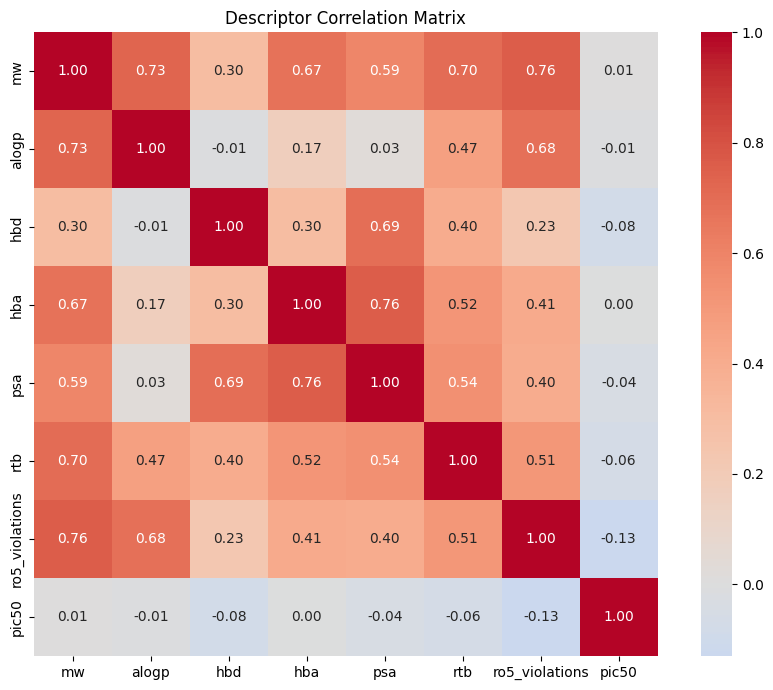

In [18]:
corr_cols = ["mw", "alogp", "hbd", "hba", "psa", "rtb", "ro5_violations", "pic50"]

corr = qsar_raw[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Descriptor Correlation Matrix")
plt.tight_layout()
plt.show()

In [19]:
print(qsar_raw["assay_type"].value_counts())
print()
print(qsar_raw.groupby("assay_type")["pic50"].describe().round(2))

assay_type
B    920
F    534
A    126
Name: count, dtype: int64

            count  mean   std   min   25%   50%   75%    max
assay_type                                                  
A            68.0  5.63  1.36  4.03  4.77  5.20  6.29   9.80
B           637.0  6.80  1.16  4.00  5.86  6.69  7.66  10.04
F           386.0  7.02  1.17  4.41  6.06  7.16  7.96   9.91


Next Steps

The exploratory analysis above informs the following preprocessing decisions 
for Phase 2:

- Drop records where `relation != '='` (censored measurements)
- Drop 9 implausible IC50 values (sub-picomolar, relation = "=", no pIC50)
- Drop compounds missing Lipinski descriptors (14 rows)
- Drop compounds missing canonical SMILES (2 rows)
- Address multicollinearity between mw/alogp and hba/psa in linear models via regularization

**Phase 2 (preprocessing and modeling) to follow.**